# Pseudomode mapping for spin-boson model with Ohmic bath

## Introduction

This notebook applies the approach of (Pleasance et al) to simulate the reduced system dynamics of the spin-boson model with an Ohmic bath.

The Hamiltonian of a generic open system model with bosonic bath is given by 
\begin{align*}
    H &:= H_S + H_B + H_{SB} \\
      &= \frac{\epsilon}{2}\sigma_z + \frac{\Delta}{2}\sigma_x + \sum_k\omega_ka^{\dagger}_ka_k + \sigma_z\otimes B,
\end{align*}
where $\sigma_{x,z}$ are Pauli spin-$\frac{1}{2}$ operators, $a_k$ ($a^{\dagger}_k$) is the annihilation (creation) operator of the $k$-th bath mode, and $B = \sum_k(g^*_ka_k + g_ka^{\dagger}_k)$. 

Moreover, the bath is initially in the thermal state $\rho_B = \exp(-\beta H_B)/{\rm Tr}[\exp(-\beta H_B)]$ at inverse temperature $\beta = 1/k_BT$. 

The bath correlation function (BCF) $C^B(t) = {\rm Tr}[e^{iH_Bt}Be^{-iH_Bt}B\rho_B]$ for a power law spectral density 
\begin{equation*}
J(\omega) = \alpha\omega^s\omega^{1-s}_ce^{-\omega/\omega_c}
\end{equation*}
admits the analytical form
\begin{equation*}
    C^B(t) = \frac{\alpha}{\pi}\omega^{1-s}_c\beta^{-(s+1)}\Gamma(s+1)\bigg[
        \zeta\left(s+1, \frac{1 - \beta\omega_c - i\omega_ct}{\beta\omega_c}\right) + \zeta\left(s+1, \frac{1 + i\omega_ct}{\beta\omega_c}\right)\bigg],
\end{equation*}
where $\Gamma(s+1) = s!$  is the Gamma function, and $\zeta(s,x)$ is the (generalised) zeta function
\begin{equation*}
    \zeta(s,x) = \sum^{\infty}_{n=0}\frac{1}{(n+x)^s}. 
\end{equation*}

In [36]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
import matplotlib as mpl 
from scipy.linalg import expm
from numpy import linalg

In [37]:
# Parameters (units of system energy eps)
T = 0.5
om_cut = 5
s = 1
N_exp = 5
alph = 0.5

tlist = np.linspace(0, 5, 500)
omlist = np.linspace(-20, 20, 500)

## Fitting of bath correlation function

To extract the pseudomode parameters, we first need to fit $C^B(t)$ with a sum of $N$ complex exponentials
\begin{equation*}
    C^E(t) = -i\sum^N_{l=1}r_le^{-iz_lt},
\end{equation*}
where $z_l$ denote pole locations of $\gamma'(\omega) = 2\,{\rm Re}\int^{\infty}_{0}dt\,C^E(t)e^{i\omega t}$ in the lower half complex $\omega$-plane, and are $r_l$ their corresponding residues.

We consider an Ohmic spectral density ($s=1$):
\begin{equation*}
    J(\omega) = \alpha\omega e^{-\omega/\omega_c}. 
\end{equation*}

In [38]:
# Fit bath correlation function with N_exp complex exponentials ck * exp(-vk * t)
bath = qt.OhmicEnvironment(T=T, alpha=alph, wc=om_cut, s=s)
approx_env, info = bath.approximate("prony", tlist, Nr=N_exp)

The error in the fit of the BCF and/or bath spectrum may be quantified through the measures
\begin{equation*}
    \Delta C(t) = |C^B(t) - C^E(t)|,
\end{equation*}
and 
\begin{equation*}
    \Delta\gamma(\omega) = |\gamma(\omega) - \gamma'(\omega)|.
\end{equation*}

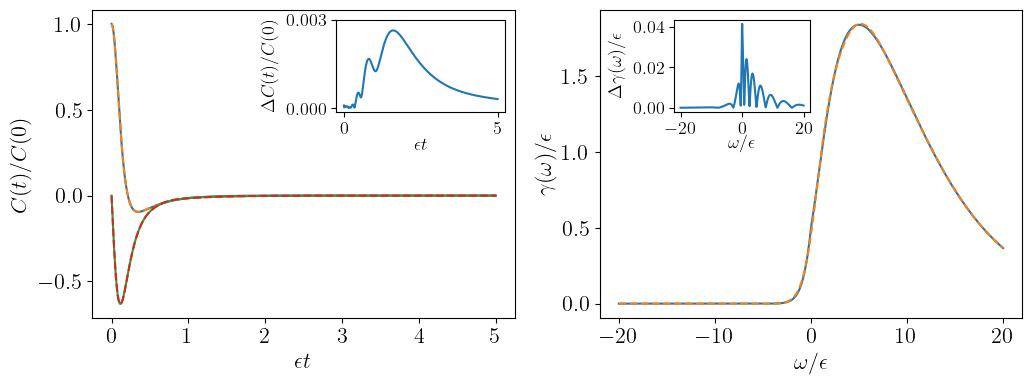

In [39]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

#matplotlib.rcParams['figure.figsize'] = (7, 5)
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 14
mpl.rcParams['axes.titlesize'] = 15
mpl.rcParams['text.usetex'] = True

fig1, ax1 = plt.subplots(1,2, figsize=(12,4))

c0 = np.real(bath.correlation_function([0])[0]) 

# Bath correlation function
# Real part
ax1[0].plot(tlist, np.real(bath.correlation_function(tlist)) / c0, label = r'$\mathrm{Exact \, (real)}$')
ax1[0].plot(tlist, np.real(approx_env.correlation_function(tlist)) / c0, linestyle='--', label = r'$\mathrm{Fit \, (real)}$')
# Imaginary part (Im C(0) = 0)
ax1[0].plot(tlist, np.imag(bath.correlation_function(tlist)) / c0, label = r'$\mathrm{Exact \, (imag)}$')
ax1[0].plot(tlist, np.imag(approx_env.correlation_function(tlist)) / c0, linestyle='--', label = r'$\mathrm{Fit \, (imag)}$')

ax1[0].set_xlabel(r'$\epsilon t$')
ax1[0].set_ylabel(r'$C(t)/C(0)$')
#ax1[0].legend()

# Error - BCF
bcf_err = np.abs(bath.correlation_function(tlist) - approx_env.correlation_function(tlist))

ax1_inset_left = inset_axes(ax1[0], width='40%', height='30%', loc='upper right')
ax1_inset_left.plot(tlist, bcf_err / c0)

ax1_inset_left.tick_params(labelsize=13)
ax1_inset_left.set_xticks([min(tlist), max(tlist)])
ax1_inset_left.set_yticks([0, np.round(np.max(bcf_err) / c0, 3)])
ax1_inset_left.set_ylabel(r'$\Delta C(t) / C(0)$', fontsize=13, labelpad=5)
ax1_inset_left.set_xlabel(r'$\epsilon t$', fontsize=13, labelpad=0)

# Bath spectrum
ax1[1].plot(omlist, bath.power_spectrum(omlist), label=r'$\mathrm{Exact}$')
ax1[1].plot(omlist, approx_env.power_spectrum(omlist), linestyle='--', label=r'$\mathrm{Fit}$')

ax1[1].set_xlabel(r'$\omega/\epsilon$')
ax1[1].set_ylabel(r'$\gamma(\omega)/\epsilon$')
#ax1[1].legend()

# Error - spectrum 
spec_err = np.abs(bath.power_spectrum(omlist) - approx_env.power_spectrum(omlist))

ax1_inset_right = inset_axes(ax1[1], width='32%', height='30%',
                             bbox_to_anchor=(-0.48, 0, 1, 1),  # (x, y, width, height)
                             bbox_transform=ax1[1].transAxes)

ax1_inset_right.plot(omlist, spec_err)

ax1_inset_right.tick_params(labelsize=13)
ax1_inset_right.set_yticks([0, 0.5 * np.round(np.max(spec_err), 2), np.round(np.max(spec_err),2)])
ax1_inset_right.set_ylabel(r"$\Delta\gamma(\omega)/\epsilon$", fontsize=13, labelpad=5)
ax1_inset_right.set_xlabel(r'$\omega/\epsilon$', fontsize=13, labelpad=-2)

plt.show()

In [40]:
print(info['summary'], '\n')

print(r'C(0) =', c0)

Result of fitting Correlation Function with 5 terms: 
 
 Parameters|   ckr    |   cki    |   vkr    |  vki 
 1         |-3.15e-02 |-9.65e-03 | 2.07e+01 |4.38e+01
 2         |-3.03e-01 | 5.98e-01 | 1.47e+01 |2.34e+01
 3         | 1.94e+00 | 1.73e+00 | 9.53e+00 |1.13e+01
 4         |-1.88e-01 |-9.06e-01 | 2.29e+00 |4.00e-01
 5         | 2.68e+00 |-1.41e+00 | 5.22e+00 |4.06e+00
 
A RMSE of  3.90e-05-1.27e-05j was obtained for the Correlation Function.
The current fit took  0.320257 seconds. 

C(0) = 4.092931899686425


In [41]:
info['params']

[(np.float64(-0.03152020079948495),
  np.float64(-0.009646963317323735),
  np.float64(20.72978203118528),
  np.float64(43.7982788068849)),
 (np.float64(-0.3026694467631721),
  np.float64(0.5982034055139429),
  np.float64(14.727730020556065),
  np.float64(23.400472918902068)),
 (np.float64(1.9370105026509834),
  np.float64(1.7281810539434077),
  np.float64(9.525459318446945),
  np.float64(11.255249937685925)),
 (np.float64(-0.1875838382960248),
  np.float64(-0.9060681407522596),
  np.float64(2.287060012789537),
  np.float64(0.4004706352090211)),
 (np.float64(2.6774256406606263),
  np.float64(-1.4109577014459476),
  np.float64(5.223247871923215),
  np.float64(4.057719571364848))]

We may reexpress the fitted correlation function in the form 
\begin{equation}
C^E(t) = \boldsymbol{g}^Te^{-i\boldsymbol{\Lambda} t}\boldsymbol{g}
\end{equation}
for $t\geq0$, where $\boldsymbol{\Lambda} = {\rm diag}(z_1,...,z_N)$ and $\boldsymbol{g} = (\sqrt{-ir_1},...,\sqrt{-ir_N})^T$.

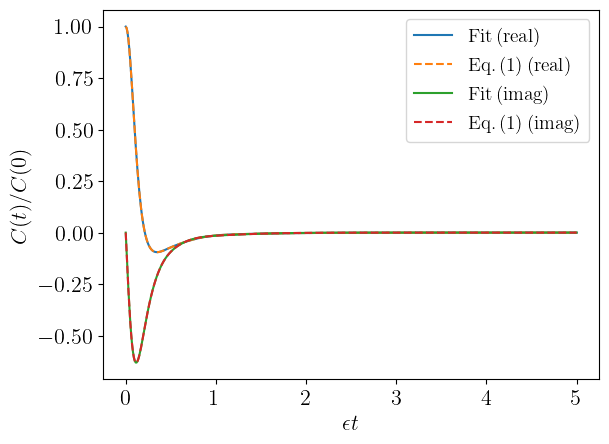

In [43]:
# Square root of complex coefficients 
r = np.array([np.sqrt(p[0] + 1j*p[1]) for p in info['params']])
Lmb = [-p[2] - 1j*p[3] for p in info['params']]
Lmb = 1j*np.diag(Lmb)

fig3, ax3 = plt.subplots()

ax3.plot(tlist, np.real(approx_env.correlation_function(tlist)) / c0, label=r'$\mathrm{Fit \, (real)}$')
ax3.plot(tlist, [np.real(np.array(r.T.dot(expm(-1j*Lmb*t).dot(r)))) / c0 for t in tlist], linestyle='--', label=r'$\mathrm{Eq. \, (1) \, (real)}$')
ax3.plot(tlist, np.imag(approx_env.correlation_function(tlist)) / c0, label=r'$\mathrm{Fit \, (imag)}$')
ax3.plot(tlist, [np.imag(np.array(r.T.dot(expm(-1j*Lmb*t).dot(r)))) / c0 for t in tlist], linestyle='--', label=r'$\mathrm{Eq. \, (1) \, (imag)}$')

ax3.set_xlabel(r'$\epsilon t$')
ax3.set_ylabel(r'$C(t)/C(0)$')
ax3.legend()

### Pseudomode parameters

We now look to extract the pseudomode parameters $\boldsymbol{g}$ (system-pseudomode couplings) and $\boldsymbol{Z}$ (self energies, internal couplings and decay rates) via a gauge transformation $\{\boldsymbol{g},\boldsymbol{\Lambda}\} \rightarrow \{\boldsymbol{g'},\boldsymbol{Z}\}$ of the BCF:
\begin{equation*}
    C^E(t) = \boldsymbol{g}'{}^Te^{-i\boldsymbol{Z}t}\boldsymbol{g}'.
\end{equation*}
To this end, we write $\boldsymbol{g'} = \boldsymbol{U}\boldsymbol{g}$, $\boldsymbol{Z} = \boldsymbol{U}\boldsymbol{\Lambda}\boldsymbol{U}^T$, where  
\begin{equation*}
    \boldsymbol{U} = \boldsymbol{S}e^{i\boldsymbol{R}},
\end{equation*}
and $\boldsymbol{S}^T = \boldsymbol{S}^{-1}$, $\boldsymbol{R} = -i\alpha(\boldsymbol{g}^*\boldsymbol{g}^T - \boldsymbol{g}\boldsymbol{g}^{\dagger})$. 

Note this always results in real couplings 
\begin{equation*}
        \boldsymbol{g'} = \frac{1}{\sqrt{2(\mu+1)}}\boldsymbol{S}(\boldsymbol{g} + \boldsymbol{g}^*),
\end{equation*}
but potentially nonpositive $\boldsymbol{\gamma} = -2\,{\rm Im}\,\boldsymbol{Z} = {\rm diag}(\gamma_1,...,\gamma_N)$.

NB: typically observed that only one decay rate of $\boldsymbol{\gamma}$ is negative for $N>2$.


The parameters $\{\boldsymbol{g'},\boldsymbol{Z}\}$ can be mapped directly onto the pseudomode master equation (PMME)
\begin{equation*}
    \dot{\rho} = -i[H',\rho] + \sum^N_{k=1}\gamma_l\Big(b_l\rho b^{\dagger}_l - \tfrac{1}{2}\{b^{\dagger}_lb_l,\rho\}\Big)
\end{equation*}
where $H' = \frac{\epsilon}{2}\sigma_z + \frac{\Delta}{2}\sigma_x + H_E + \sigma_z\otimes B'$, and
\begin{align*}
    H_E &= \sum_{k,l}\xi_{kl}b^{\dagger}_kb_l, \\
    B' &= \sum_l g'_l(b_l + b^{\dagger}_l),
\end{align*}
with $\boldsymbol{\xi} = {\rm Re}\,\boldsymbol{Z}$. 

NB: since $\gamma_l$ can potentially be negative, the PMME will generally be in quasi-GKSL form. 

In [ ]:
# # Pseudomode parameters
# r = r / np.sqrt(c0)

# # CHECK
# mu = r.dot(np.conj(r))
# alpha = (1/(np.sqrt(mu*mu-1))) * np.arctanh(np.sqrt((mu-1)/(mu+1))) 

# theta = alpha * np.sqrt(mu*mu-1)

# # exp of R matrix
# exp_R = np.identity(len(r)) + (1/(mu*mu-1)) * ((np.cosh(theta)*(2*mu-1)-mu) * np.outer(np.conj(r), r)
#                                           - (mu - np.cosh(theta)) * np.outer(r, np.conj(r))
#                                           - (np.cosh(theta)-1) * np.outer(r, r)
#                                           - (np.cosh(theta)-1) * np.outer(np.conj(r), np.conj(r)))

# # First part of transformation
# gm_0 = -2 * np.imag(exp_R.dot(Lmb.dot(exp_R.T)))  # check
# xi_0 = np.real(exp_R.dot(Lmb.dot(exp_R.T)))

# S = linalg.eig(gm_0)[1].T  # obtain S from eigenvectors of gm_0

# # Pseudomode coupling + decay rates
# xi = S.dot(xi_0.dot(S.T))
# gm = S.dot(gm_0.dot(S.T))
# # System-pseudomode couplings
# g = np.sqrt(c0) * S.dot((1/(np.sqrt(2*(mu+1))))*(r + np.conj(r)))

# print('g = ')
# print(np.real(g))
# print('\n')
# print('xi = ')
# print(xi)
# print('\n')
# print('gamma = ')
# print(np.diag(gm))

g = 
[ 1.70574836 -0.73843705  0.3431507  -0.00203094 -0.72125687]


xi = 
[[ 7.59498673 -3.43368479 -7.80264254 -9.41679683 -4.36862764]
 [-3.43368479  2.71802094  4.15009247  1.89950352 -1.13810504]
 [-7.80264254  4.15009247 40.16040714 -7.39024997  2.30767355]
 [-9.41679683  1.89950352 -7.39024997 21.72610238 -4.2429594 ]
 [-4.36862764 -1.13810504  2.30767355 -4.2429594  10.71230182]]


gamma = 
[-7.56730743  8.41803348 43.14901681 37.42308418 23.56353841]


In [57]:
from pseudomodes.pure_dephasing import pm_parameters

rk = 1j * (r ** 2)
g, xi, gm, info = pm_parameters(rk=rk, zk=Lmb, info=True)

print(info['all'])

g = 
 [ 1.70573 -0.73839  0.34315 -0.00205 -0.72124]

xi = 
 [[ 7.5953  -3.4337  -7.80317 -9.41713 -4.36871]
 [-3.4337   2.71802  4.15017  1.89933 -1.13821]
 [-7.80317  4.15017 40.15989 -7.39078  2.30781]
 [-9.41713  1.89933 -7.39078 21.72633 -4.24324]
 [-4.36871 -1.13821  2.30781 -4.24324 10.71264]]

gm = 
 [-7.56835  8.4181  43.14914 37.42364 23.56403]


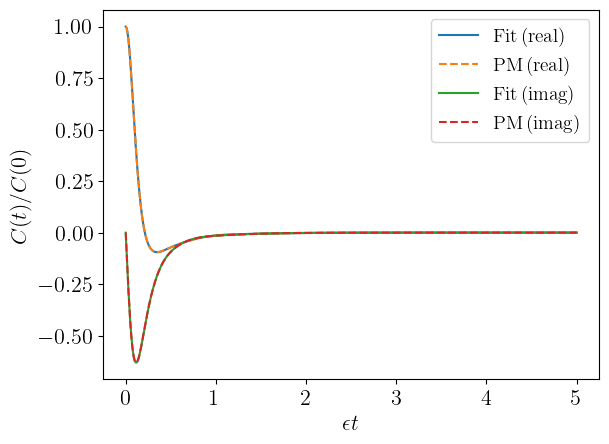

In [58]:
# Plot pseudomode correlation function with parameters {g, Z} against correlation fit
Z  = xi - 0.5*1j*gm
g = np.real(g)
corr_pm = np.array([g.T.dot(expm(-1j*Z*t).dot(g)) for t in tlist])

fig4, ax4 = plt.subplots()
ax4.plot(tlist, np.real(approx_env.correlation_function(tlist)) / c0, label=r'$\mathrm{Fit \, (real)}$')
ax4.plot(tlist, (np.real(corr_pm)) / c0, '--', label=r'$\mathrm{PM \, (real)}$')
ax4.plot(tlist, np.imag(approx_env.correlation_function(tlist)) / c0, label=r'$\mathrm{Fit \, (imag)}$')
ax4.plot(tlist, np.imag(corr_pm) / c0, '--', label=r'$\mathrm{PM \, (imag)}$')

ax4.set_xlabel(r'$\epsilon t$')
ax4.set_ylabel(r'$C(t)/C(0)$')
ax4.legend()


## PMME simulation: independent boson model (IBM)

To benchmark the PMME results, we consider an exactly solvable version of the spin-boson model - the independent boson model - where the system undergoes a purely dephasing dynamics:
\begin{equation*}
 H = \frac{\epsilon}{2}\sigma_z + \sum_k\omega_ka^{\dagger}_ka_k + \sigma_z\otimes B.
\end{equation*}
The system Bloch vector in this case evolves according to
\begin{equation*}
    \begin{pmatrix}
    \langle \sigma_x(t)\rangle \\ 
    \langle \sigma_y(t)\rangle \\ 
    \langle \sigma_z(t)\rangle
    \end{pmatrix}
    =
    \begin{pmatrix}
    2\,{\rm Re}[e^{i\epsilon t + \phi(t)}\rho_{10}] \\ 
    2\,{\rm Im}[e^{i\epsilon t + \phi(t)}\rho_{10}]  \\ 
    \langle \sigma_z(0)\rangle
    \end{pmatrix},
\end{equation*}
where $\rho_{10} = \langle 1|\rho_S(t)|0\rangle$, and 
\begin{equation*}
    \phi(t) = -\frac{4}{\pi}\int^{\infty}_0d\omega\frac{J(\omega)}{\omega^2}\coth\left(\frac{\beta\omega}{2}\right)(1-\cos\omega t).
\end{equation*}


In [59]:
tlist_pm = np.linspace(0, 10, 500)

# Local PM dims
N1, N2, N3, N4, N5 = 7, 2, 3, 4, 3
Nlist = [N1, N2, N3, N4, N5]

# Initial system + PM state
init_state = qt.tensor([qt.ket2dm((qt.basis(2) + qt.basis(2,1)).unit())] + [qt.fock_dm(N) for N in Nlist])

sigx = qt.tensor([qt.sigmax()] + [qt.identity(N) for N in Nlist])
sigy = qt.tensor([qt.sigmay()] + [qt.identity(N) for N in Nlist])
sigz = qt.tensor([qt.sigmaz()] + [qt.identity(N) for N in Nlist])

b_ops = []
for n in range(len(Nlist)): 
  b_ops.append(qt.tensor([qt.identity(2)] + [qt.destroy(N) if n == idx else qt.identity(N) for idx, N in enumerate(Nlist)]))


In [60]:
# Hamiltonian
H_S = 1/2 * sigz
H_E = 0 
H_I = 0
for i in range(len(b_ops)):
    H_I += g[i] * sigz * (b_ops[i] + b_ops[i].dag())
    for j in range(len(b_ops)):
        H_E += xi[i][j] * b_ops[i].dag() * b_ops[j] 

H = H_S + H_E + H_I

In [61]:
# Construct GKSL part of dissipator
L_sys_pm = qt.liouvillian(H=H, c_ops=[np.sqrt(dr) * b_ops[i] if dr > 0 else 0 * b_ops[i] for i, dr in enumerate(np.diag(gm))])

# Add non-GKSL part (negative decay rates)
for i, dr in enumerate(np.diag(gm)):
    if dr < 0:
        L_sys_pm -= qt.lindblad_dissipator(a=np.sqrt(np.abs(dr)) * b_ops[i])

In [62]:
# Solve quasi-Lindblad ME
result = qt.mesolve(L_sys_pm, init_state, tlist_pm, e_ops=[sigx, sigy] + [op.dag() * op for op in b_ops], options={'progress_bar': True})

10.0%. Run time:  45.22s. Est. time left: 00:00:06:46
20.0%. Run time:  93.02s. Est. time left: 00:00:06:11
30.1%. Run time: 138.40s. Est. time left: 00:00:05:22
40.1%. Run time: 189.44s. Est. time left: 00:00:04:43
50.1%. Run time: 245.76s. Est. time left: 00:00:04:04
60.1%. Run time: 290.70s. Est. time left: 00:00:03:12
70.1%. Run time: 334.09s. Est. time left: 00:00:02:22
80.2%. Run time: 377.49s. Est. time left: 00:00:01:33
90.2%. Run time: 424.70s. Est. time left: 00:00:00:46
100.0%. Run time: 464.62s. Est. time left: 00:00:00:00
Total run time: 464.63s


## Benchmarking

Relative error for each Bloch component $\langle\sigma_i(t)\rangle$,
\begin{equation*}
    \varepsilon_i = \frac{|\Delta\langle\sigma_i(t)\rangle|}{|\langle\sigma_i(t)\rangle|},
\end{equation*}
where $\Delta\langle\sigma_i(t)\rangle = \langle\sigma_i(t)\rangle - {\rm Tr}[(\sigma_i\otimes\mathbb{I}_E)\rho(t)]$.

/Users/GraemePleasance/Documents/PM theory 2/Python/pseudomodes/pure_dephasing.py:254: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral = lambda t: quad(lambda w: dephase_integrand(w, t, T, sd_type=sd_type, coup=kwargs['coup'], w_cut=kwargs['w_cut'], s=kwargs['s']), 0, np.inf)[0]
/var/folders/cl/lf0z7k5n0p91rtvfr_fc1hr00000gn/T/ipykernel_33583/923514522.py:23: RuntimeWarning: invalid value encountered in divide
  ax5[1].plot(tlist_pm, 100 * np.abs(evolved_bloch_vector[1] - result.expect[1]) / (np.abs(evolved_bloch_vector[1])), label=r'$i=y$')


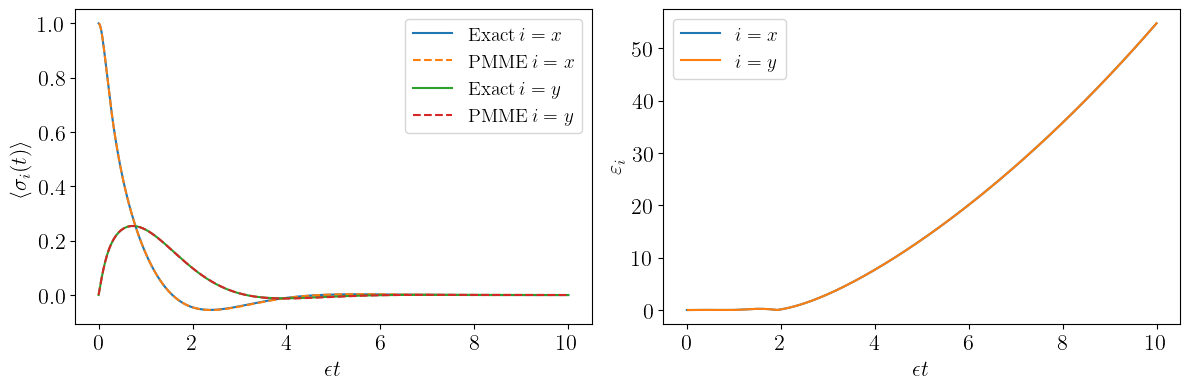

In [63]:
from pseudomodes.pure_dephasing import dephase_exp

# Initial Bloch vector
init_tls_state = init_state.ptrace(0)

bloch_vector = np.array([qt.expect(qt.sigmax(),init_tls_state), qt.expect(qt.sigmay(),init_tls_state), qt.expect(qt.sigmaz(),init_tls_state)])

# Compute time-evoled Bloch vector from dephase_exp (decoherence function)
evolved_bloch_vector = dephase_exp(tlist_pm, bloch_vector, eps=1, T=T, sd_type='PowerLaw', coup=alph, w_cut=om_cut, s=s)

fig5, ax5 = plt.subplots(1,2, figsize=(12,4))

ax5[0].plot(tlist_pm, evolved_bloch_vector[0], label=r'$\mathrm{Exact} \, i=x$')
ax5[0].plot(tlist_pm, result.expect[0], linestyle='--', label=r'$\mathrm{PMME} \, i=x$')
ax5[0].plot(tlist_pm, evolved_bloch_vector[1], label=r'$\mathrm{Exact} \, i=y$')
ax5[0].plot(tlist_pm, result.expect[1], linestyle='--', label=r'$\mathrm{PMME} \, i=y$')

ax5[0].set_xlabel(r'$\epsilon t$')
ax5[0].set_ylabel(r'$\langle \sigma_i(t)\rangle$')
ax5[0].legend()

ax5[1].plot(tlist_pm, 100 * np.abs(evolved_bloch_vector[0] - result.expect[0]) / (np.abs(evolved_bloch_vector[0])), label=r'$i=x$')
ax5[1].plot(tlist_pm, 100 * np.abs(evolved_bloch_vector[1] - result.expect[1]) / (np.abs(evolved_bloch_vector[1])), label=r'$i=y$')

ax5[1].set_xlabel(r'$\epsilon t$')
ax5[1].set_ylabel(r'$\varepsilon_i$')
ax5[1].legend()

fig5.tight_layout()

plt.show()

Hence, the PMME results show a maximum relative error of roughly 60\%. In absolute terms, however, this error is small due to $\langle\sigma_{x,y}(t)\rangle$ and ${\rm Tr}[(\sigma_{x,y}\otimes\mathbb{I}_E)\rho(t)]$ being near zero as the system approaches equilibrium.  

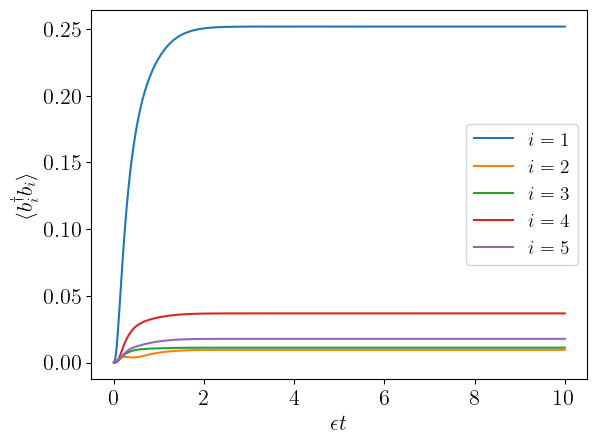

In [64]:
# Pseudomode populations - note these can be negative since the PMME is in quasi-GKSL form
fig6, ax6 = plt.subplots()

for b in range(len(b_ops)):
    ax6.plot(tlist_pm, result.expect[b+2], label=r'$i={}$'.format(b+1))

ax6.set_xlabel(r'$\epsilon t$')
ax6.set_ylabel(r'$\langle b^{\dagger}_ib_i\rangle $')
ax6.legend()

plt.show()